<h2>
    <b>Auto Insurance Fraud Detection

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [35]:
df = pd.read_csv(r"C:\Users\gagan\Desktop\auto_insurance_fraud_detection_using_ml_and_genai\data\insurance_claims.csv")

### overview of data

In [36]:
df.head(5)

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [37]:
df.tail(5)

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,...,?,87200,17440,8720,61040,Honda,Accord,2006,N,NaN
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,...,?,108480,18080,18080,72320,Volkswagen,Passat,2015,N,NaN
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,...,YES,67500,7500,7500,52500,Suburu,Impreza,1996,N,NaN
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,...,YES,46980,5220,5220,36540,Audi,A5,1998,N,NaN
999,456,60,556080,1996-11-11,OH,250/500,1000,766.19,0,612260,...,?,5060,460,920,3680,Mercedes,E400,2007,N,NaN


#### columns and classification of columns based on dt

In [38]:
print(df.columns)
print(len(df.columns))

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital-gains', 'capital-loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported', '_c39'],
      dtype='object')
40


In [39]:
for i in df.columns:
    print(f"{i} = {df[i].unique()}")
    print("\n")
    

months_as_customer = [328 228 134 256 137 165  27 212 235 447  60 121 180 473  70 140 160 196
 460 217 370 413 237   8 257 202 224 241  64 166 155 114 149 147  62 289
 431 199  79 116  37 106 269 265 163 355 175 192 430  91 223 195  22 439
  94  11 151 154 245 119 215 295 254 107 478 128 338 271 222 120 270 319
 194 227 244  78 200 284 275 153  31  41 127  61 207 219  80 325  29 239
 279 350 464 118 298  87 261 453 210 168 390 258 225 164 255 206 203 211
 274  81 280 112  24  93 171 124 287 122 398 214 209  82 193 288 104 101
 375 461 428  45 136 216 278 108  14 276  47  73 294 324  53 426 111  86
 296 125 177 238 449 252 359  19 285  30 342 468 343 404  63 335 142 272
  69  38 281 246 330 362 371 377 172  99 249 190 174  95   2 117 242 440
  20 208 156 232  84 394  35 369 332 243 264  32 259 186 201 436 189 105
  88  40  59  39 123 231 247  48 267 286 253  10 158   1  85 233 266  97
 399 305 129 283  96 176 159 290 299  66 334 429  15 230 250  65 475  77
 229 110 292 451 150 291 162 3

In [40]:
print(df.select_dtypes("object").columns)
print(len(df.select_dtypes("object").columns))

Index(['policy_bind_date', 'policy_state', 'policy_csl', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'incident_date', 'incident_type',
       'collision_type', 'incident_severity', 'authorities_contacted',
       'incident_state', 'incident_city', 'incident_location',
       'property_damage', 'police_report_available', 'auto_make', 'auto_model',
       'fraud_reported'],
      dtype='object')
21


In [41]:
print(df.select_dtypes("int").columns)
print(len(df.select_dtypes("int").columns))

Index(['months_as_customer', 'age', 'policy_number', 'policy_deductable',
       'umbrella_limit', 'insured_zip', 'capital-gains', 'capital-loss',
       'incident_hour_of_the_day', 'number_of_vehicles_involved',
       'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim',
       'property_claim', 'vehicle_claim', 'auto_year'],
      dtype='object')
17


In [42]:
print(df.select_dtypes("float").columns)
print(len(df.select_dtypes("float").columns))

Index(['policy_annual_premium', '_c39'], dtype='object')
2


#### statistical summary of the data

In [43]:
df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


In [44]:
df.describe(include = "object")

,policy_bind_date,policy_state,policy_csl,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,incident_date,incident_type,...,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,property_damage,police_report_available,auto_make,auto_model,fraud_reported
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,...,1000,909,1000,1000,1000,1000,1000,1000,1000,1000
unique,951,3,3,2,7,14,20,6,60,4,...,4,4,7,7,1000,3,3,14,39,2
top,2006-01-01,OH,250/500,FEMALE,JD,machine-op-inspct,reading,own-child,2015-02-02,Multi-vehicle Collision,...,Minor Damage,Police,NY,Springfield,9935 4th Drive,?,?,Saab,RAM,N
freq,3,352,351,537,161,93,64,183,28,419,...,354,292,262,157,1,360,343,80,43,753


#### check for missing values

In [45]:
df.isnull().sum()

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted            91
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
property_damage             

In [46]:
from sklearn.impute import SimpleImputer

impute = SimpleImputer(strategy='most_frequent')
df[['authorities_contacted']] = impute.fit_transform(df[['authorities_contacted']])

In [47]:
df.isnull().sum()

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted             0
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
property_damage             

#### drop columns that are unnecessary 

In [48]:
unused_columns = ['policy_number', 'insured_zip', 'incident_location', 'incident_city', 'policy_bind_date', 'incident_date', '_c39']
df.drop(columns = unused_columns, inplace = True)

#### label encoding

In [49]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = df.select_dtypes(include = ['object']).columns
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

#### splitting

In [50]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [51]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 42)
X, y = smote.fit_resample(X, y)

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y)

#### feature scaling

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [54]:
corr_matrix = pd.DataFrame(X_train).corr()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k = 1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]
X_train = np.delete(X_train, to_drop, axis = 1)
X_test = np.delete(X_test, to_drop, axis = 1)

#### modeling

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter = 1000,
                                              random_state = 42,
                                              C = 0.1),
    'Random Forest': RandomForestClassifier(n_estimators = 100,
                                            max_depth = 6,
                                            min_samples_split = 20,
                                            min_samples_leaf = 10,
                                            random_state = 42),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators = 80,
        learning_rate = 0.05,  
        max_depth = 2,  
        min_samples_split = 50,  
        min_samples_leaf = 20,  
        subsample = 0.8,
        random_state = 42
    ),
    'Naive Bayes': GaussianNB(),
}

In [56]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score

results = {}
cv = StratifiedKFold(n_splits = 15, shuffle = True, random_state = 42)  # Increase cross-validation splits
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    cv_score = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy').mean()

    results[name] = {
        'Training Accuracy': train_accuracy,
        'Testing Accuracy': test_accuracy,
        'Cross-Validation Accuracy': cv_score,
        'Classification Report': classification_report(y_test, y_test_pred, output_dict=True),
        'Confusion Matrix': confusion_matrix(y_test, y_test_pred)
    }

for name, scores in results.items():
    print(f"\n{name}:")
    print(f"  Training Accuracy: {scores['Training Accuracy']:.4f}")
    print(f"  Testing Accuracy: {scores['Testing Accuracy']:.4f}")
    print(f"  Cross-Validation Accuracy: {scores['Cross-Validation Accuracy']:.4f}\n")
    print(f"  Confusion Matrix:\n {scores['Confusion Matrix']}\n")
    print(f"  Classification Report:\n {classification_report(y_test, y_test_pred)}")


Training Logistic Regression...

Training Random Forest...

Training Gradient Boosting...

Training Naive Bayes...

Logistic Regression:
  Training Accuracy: 0.7558
  Testing Accuracy: 0.7219
  Cross-Validation Accuracy: 0.7442

  Confusion Matrix:
 [[102  49]
 [ 35 116]]

  Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.60      0.69       151
           1       0.68      0.85      0.76       151

    accuracy                           0.73       302
   macro avg       0.74      0.73      0.72       302
weighted avg       0.74      0.73      0.72       302


Random Forest:
  Training Accuracy: 0.8929
  Testing Accuracy: 0.8377
  Cross-Validation Accuracy: 0.8522

  Confusion Matrix:
 [[132  19]
 [ 30 121]]

  Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.60      0.69       151
           1       0.68      0.85      0.76       151

    accuracy                 

#### picking up the best model

In [57]:
best_model = max(results, key = lambda x: results[x]['Testing Accuracy'])
print(f"\nBest Model: {best_model}")
print(f"Training Accuracy: {results[best_model]['Training Accuracy']:.4f}")
print(f"Testing Accuracy: {results[best_model]['Testing Accuracy']:.4f}")


Best Model: Gradient Boosting
Training Accuracy: 0.8829
Testing Accuracy: 0.8477


#### comparison  using plot

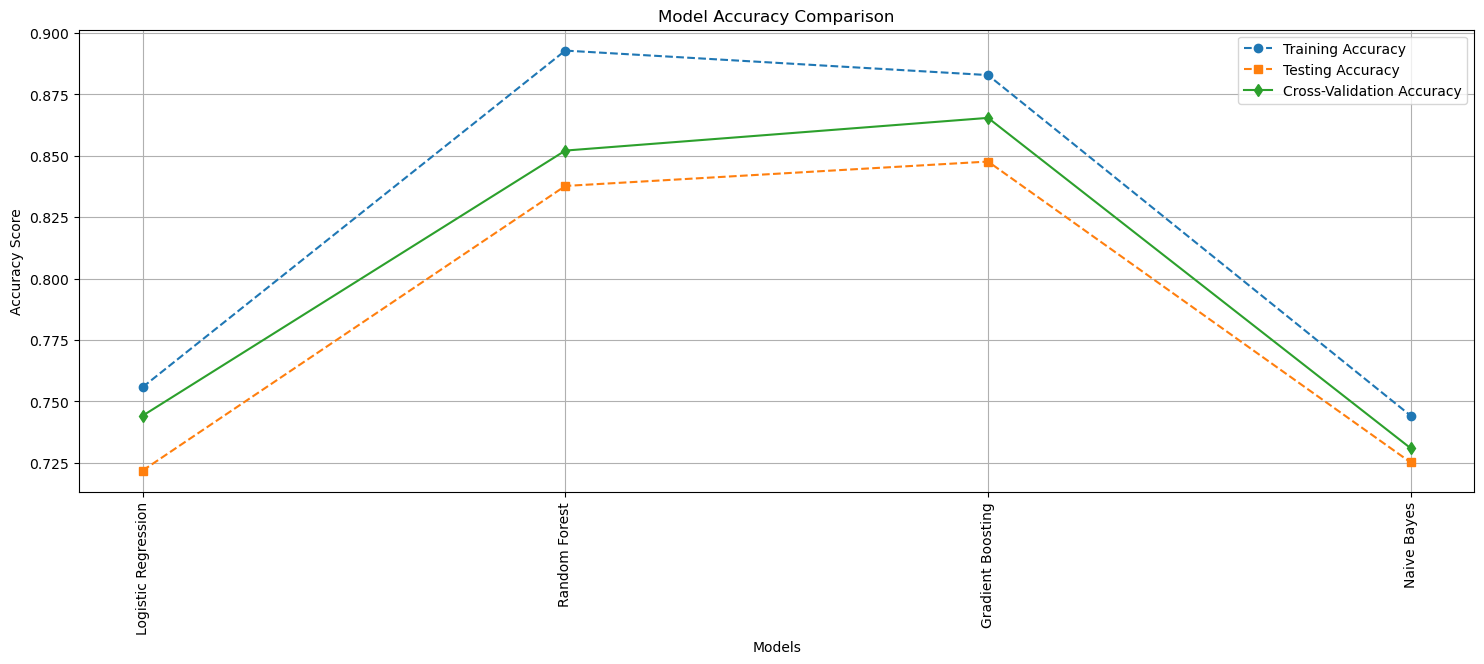

In [58]:
models = list(results.keys())
train_acc = [results[model]['Training Accuracy'] for model in models]
test_acc = [results[model]['Testing Accuracy'] for model in models]
cv_acc = [results[model]['Cross-Validation Accuracy'] for model in models]

plt.figure(figsize = (18, 6))
plt.plot(models, train_acc, marker = 'o', label = 'Training Accuracy', linestyle = '--')
plt.plot(models, test_acc, marker = 's', label = 'Testing Accuracy', linestyle = '--')
plt.plot(models, cv_acc, marker = 'd', label= 'Cross-Validation Accuracy', linestyle = '-')

plt.xticks(rotation = 90)
plt.xlabel("Models")
plt.ylabel("Accuracy Score")
plt.title("Model Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [59]:
import joblib
joblib.dump(model, 'fraud_model.joblib')
print("Model saved as fraud_model.joblib")

Model saved as fraud_model.joblib
